In [47]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [50]:
import pandas as pd

movies = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Sem_5/DMP Project/ml-1m/movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["MovieID", "Title", "Genres"]
)

ratings = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Sem_5/DMP Project/ml-1m/ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["UserID", "MovieID", "Rating", "Timestamp"]
)

users = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Sem_5/DMP Project/ml-1m/users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["UserID", "Gender", "Age", "Occupation", "Zip-code"]
)

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Users:", users.shape)

Movies: (3883, 3)
Ratings: (1000209, 4)
Users: (6040, 5)


In [51]:
display(movies.head(10))
display(ratings.head(10))
display(users.head(10))

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
5,6,F,50,9,55117
6,7,M,35,1,06810
7,8,M,25,12,11413
8,9,M,25,17,61614
9,10,F,35,1,95370


In [52]:
print("MOVIES")
movies.info()

print("\nRATINGS")
ratings.info()

print("\nUSERS")
users.info()

MOVIES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   MovieID  3883 non-null   int64 
 1   Title    3883 non-null   object
 2   Genres   3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB

RATINGS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB

USERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6

In [53]:
print(movies["Genres"].value_counts().head(20))

Genres
Drama                   843
Comedy                  521
Horror                  178
Comedy|Drama            162
Comedy|Romance          142
Drama|Romance           134
Documentary             116
Thriller                101
Action                   65
Drama|Thriller           63
Action|Thriller          48
Children's|Comedy        47
Crime|Drama              44
Drama|War                43
Romance                  40
Action|Drama             39
Animation|Children's     35
Comedy|Drama|Romance     34
Horror|Sci-Fi            33
Western                  33
Name: count, dtype: int64


In [54]:
print(users["Age"].value_counts().sort_index())

Age
1      222
18    1103
25    2096
35    1193
45     550
50     496
56     380
Name: count, dtype: int64


In [55]:
age_map = {
    1: "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+"
}

users["Age_Group"] = users["Age"].map(age_map)

print(users["Age_Group"].value_counts())

Age_Group
25-34       2096
35-44       1193
18-24       1103
45-49        550
50-55        496
56+          380
Under 18     222
Name: count, dtype: int64


In [56]:
df = ratings.merge(movies, on="MovieID")

display(df.head(10))

,UserID,MovieID,Rating,Timestamp,Title,Genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy
5,1,1197,3,978302268,"Princess Bride, The (1987)",Action|Adventure|Comedy|Romance
6,1,1287,5,978302039,Ben-Hur (1959),Action|Adventure|Drama
7,1,2804,5,978300719,"Christmas Story, A (1983)",Comedy|Drama
8,1,594,4,978302268,Snow White and the Seven Dwarfs (1937),Animation|Children's|Musical
9,1,919,4,978301368,"Wizard of Oz, The (1939)",Adventure|Children's|Drama|Musical


In [57]:
print("Total Ratings:", len(df))
print("Average Rating:", df["Rating"].mean())
print("Minimum Rating:", df["Rating"].min())
print("Maximum Rating:", df["Rating"].max())

Total Ratings: 1000209
Average Rating: 3.581564453029317
Minimum Rating: 1
Maximum Rating: 5


In [58]:
print(df["Rating"].value_counts().sort_index())

Rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


In [59]:
movie_rating_count = (
    df.groupby("Title")
      .size()
      .sort_values(ascending=False)
)

print(movie_rating_count.head(10))

Title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
dtype: int64


In [60]:
age_map = {
    1: "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+"
}

users["Age_Group"] = users["Age"].map(age_map)

users["Age_Group"].value_counts()

,count
Age_Group,
25-34,2096
35-44,1193
18-24,1103
45-49,550
50-55,496
56+,380
Under 18,222


In [61]:
age_ratings = ratings.merge(
    users[["UserID", "Age_Group"]],
    on="UserID"
)

age_ratings.groupby("Age_Group")["Rating"].mean().sort_values(ascending=False)

,Rating
Age_Group,
56+,3.766632
50-55,3.714512
45-49,3.638062
35-44,3.618162
Under 18,3.549520
25-34,3.545235
18-24,3.507573


In [62]:
age_rating_count = pd.crosstab(
    age_ratings["Age_Group"],
    age_ratings["Rating"]
)

age_rating_count

Rating,1,2,3,4,5
Age_Group,,,,,
18-24,13063,22073,47601,60241,40558
25-34,23898,44817,104287,136824,85730
35-44,9067,20253,52990,71983,44710
45-49,3409,8437,22311,30334,19142
50-55,2948,5993,18465,26484,18600
56+,1551,3001,9163,14297,10768
Under 18,2238,2983,6380,8808,6802


In [63]:
age_ratings["Age_Group"].value_counts()

,count
Age_Group,
25-34,395556
35-44,199003
18-24,183536
45-49,83633
50-55,72490
56+,38780
Under 18,27211


In [64]:
genre_df = df.assign(
    Genre=df["Genres"].str.split("|")
).explode("Genre")

genre_df[["Title", "Genre", "Rating"]].head(10)


,Title,Genre,Rating
0,One Flew Over the Cuckoo's Nest (1975),Drama,5
1,James and the Giant Peach (1996),Animation,3
1,James and the Giant Peach (1996),Children's,3
1,James and the Giant Peach (1996),Musical,3
2,My Fair Lady (1964),Musical,3
2,My Fair Lady (1964),Romance,3
3,Erin Brockovich (2000),Drama,4
4,"Bug's Life, A (1998)",Animation,5
4,"Bug's Life, A (1998)",Children's,5
4,"Bug's Life, A (1998)",Comedy,5


In [65]:
genre_avg_rating = (
    genre_df.groupby("Genre")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

genre_avg_rating

,Rating
Genre,
Film-Noir,4.075188
Documentary,3.933123
War,3.893327
Drama,3.766332
Crime,3.708679
Animation,3.684868
Mystery,3.668102
Musical,3.665519
Western,3.637770


In [66]:
genre_rating_count = (
    genre_df.groupby("Genre")["Rating"]
    .count()
    .sort_values(ascending=False)
)

genre_rating_count

,Rating
Genre,
Comedy,356580
Drama,354529
Action,257457
Thriller,189680
Sci-Fi,157294
Romance,147523
Adventure,133953
Crime,79541
Horror,76386


In [67]:
genre_rating_distribution = pd.crosstab(
    genre_df["Genre"],
    genre_df["Rating"]
)

genre_rating_distribution

Rating,1,2,3,4,5
Genre,,,,,
Action,16531,31432,70728,86579,52187
Adventure,8494,16641,37867,44343,26608
Animation,2097,3587,10973,15841,10795
Children's,5875,8637,20396,23704,13574
Comedy,21616,41073,96946,123415,73530
Crime,3219,7433,19542,28454,20893
Documentary,271,477,1446,3032,2684
Drama,12114,29154,84821,131811,96629
Fantasy,2367,4729,10491,11725,6989


In [68]:
genre_5star = (
    genre_rating_distribution[5]
    / genre_rating_distribution.sum(axis=1)
    * 100
).sort_values(ascending=False)

genre_5star

,0
Genre,
Film-Noir,38.623296
War,34.180688
Documentary,33.931732
Drama,27.255598
Crime,26.266957
Musical,25.269063
Mystery,24.986311
Animation,24.934747
Western,24.005222


In [69]:
genre_age_rating = (
    genre_df.merge(
        users[["UserID", "Age_Group"]],
        on="UserID"
    )
    .groupby(["Age_Group", "Genre"])["Rating"]
    .mean()
    .unstack()
)

genre_age_rating

Genre,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
Age_Group,,,,,,,,,,,,,,,,,,
18-24,3.447097,3.408525,3.624014,3.294257,3.460417,3.668054,3.865865,3.721930,3.353778,3.997368,3.172682,3.560291,3.525387,3.534300,3.426067,3.494634,3.853136,3.471533
25-34,3.453358,3.443163,3.701228,3.426873,3.490385,3.680321,3.946690,3.726428,3.452484,4.058725,3.200096,3.619857,3.610818,3.546730,3.443822,3.535471,3.841240,3.607826
35-44,3.538107,3.515291,3.740545,3.518423,3.561984,3.733736,3.953747,3.782512,3.482301,4.064910,3.276022,3.721587,3.697396,3.651142,3.502119,3.615934,3.901130,3.679278
45-49,3.528543,3.528963,3.734856,3.527593,3.591789,3.750661,3.966521,3.784356,3.532468,4.105376,3.262274,3.744484,3.754350,3.685990,3.482515,3.639657,3.960554,3.667135
50-55,3.611333,3.628163,3.780020,3.556555,3.646868,3.810688,3.908108,3.878415,3.581570,4.175401,3.158940,3.798254,3.885795,3.758111,3.564456,3.709668,3.974184,3.741322
56+,3.610709,3.649064,3.756233,3.621822,3.650949,3.832549,3.961538,3.933465,3.532700,4.125932,3.254401,3.886713,3.890545,3.816531,3.497746,3.719749,4.067285,3.792198
Under 18,3.506385,3.449975,3.476113,3.241642,3.497491,3.710170,3.730769,3.794735,3.317647,4.145455,3.254184,3.568306,3.631522,3.621284,3.478698,3.550373,3.895437,3.576119


In [70]:
genre_age_rating.idxmax(axis=1)


,0
Age_Group,
18-24,Film-Noir
25-34,Film-Noir
35-44,Film-Noir
45-49,Film-Noir
50-55,Film-Noir
56+,Film-Noir
Under 18,Film-Noir


In [71]:
max_genre_rating = genre_age_rating.max(axis=1)

pd.DataFrame({
    "Genre": genre_age_rating.idxmax(axis=1),
    "Average_Rating": max_genre_rating
})


,Genre,Average_Rating
Age_Group,,
18-24,Film-Noir,3.997368
25-34,Film-Noir,4.058725
35-44,Film-Noir,4.064910
45-49,Film-Noir,4.105376
50-55,Film-Noir,4.175401
56+,Film-Noir,4.125932
Under 18,Film-Noir,4.145455


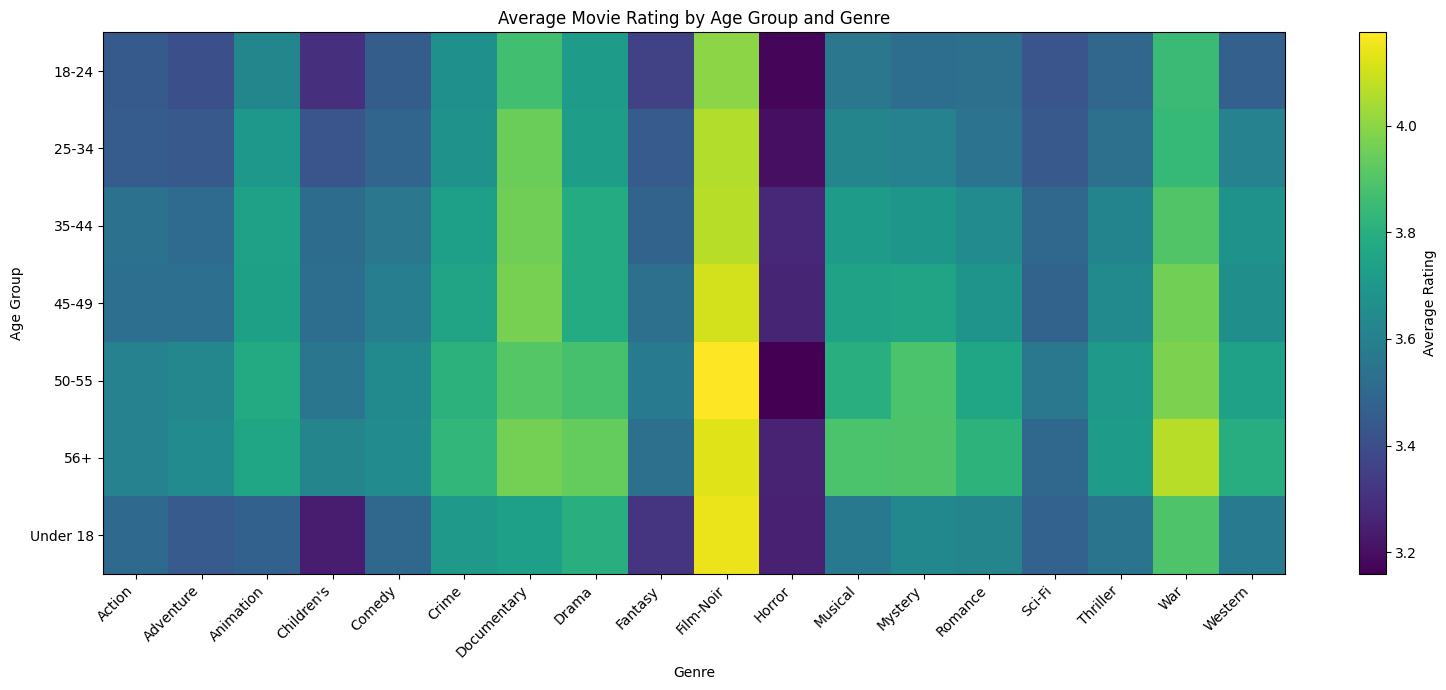

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))

plt.imshow(
    genre_age_rating,
    aspect="auto"
)

plt.xticks(
    range(len(genre_age_rating.columns)),
    genre_age_rating.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(genre_age_rating.index)),
    genre_age_rating.index
)

plt.colorbar(label="Average Rating")
plt.xlabel("Genre")
plt.ylabel("Age Group")
plt.title("Average Movie Rating by Age Group and Genre")

plt.tight_layout()
plt.show()

In [73]:
genre_pairs = (
    movies["Genres"]
    .str.get_dummies(sep="|")
)

genre_pairs.head()


,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [74]:
from itertools import combinations

pair_count = {}

for genres in movies["Genres"]:
    genre_list = genres.split("|")

    for pair in combinations(sorted(genre_list), 2):
        pair_count[pair] = pair_count.get(pair, 0) + 1

genre_pairs_count = (
    pd.Series(pair_count, name="Movie_Count")
    .sort_values(ascending=False)
)

genre_pairs_count.head(15)

Comedy      Drama         226
            Romance       204
Drama       Romance       204
Action      Thriller      133
            Adventure     128
Drama       Thriller      110
Action      Sci-Fi        107
            Drama         100
Children's  Comedy         93
Crime       Drama          90
Animation   Children's     84
Adventure   Children's     81
Drama       War            76
Sci-Fi      Thriller       70
Adventure   Sci-Fi         67
Name: Movie_Count, dtype: int64

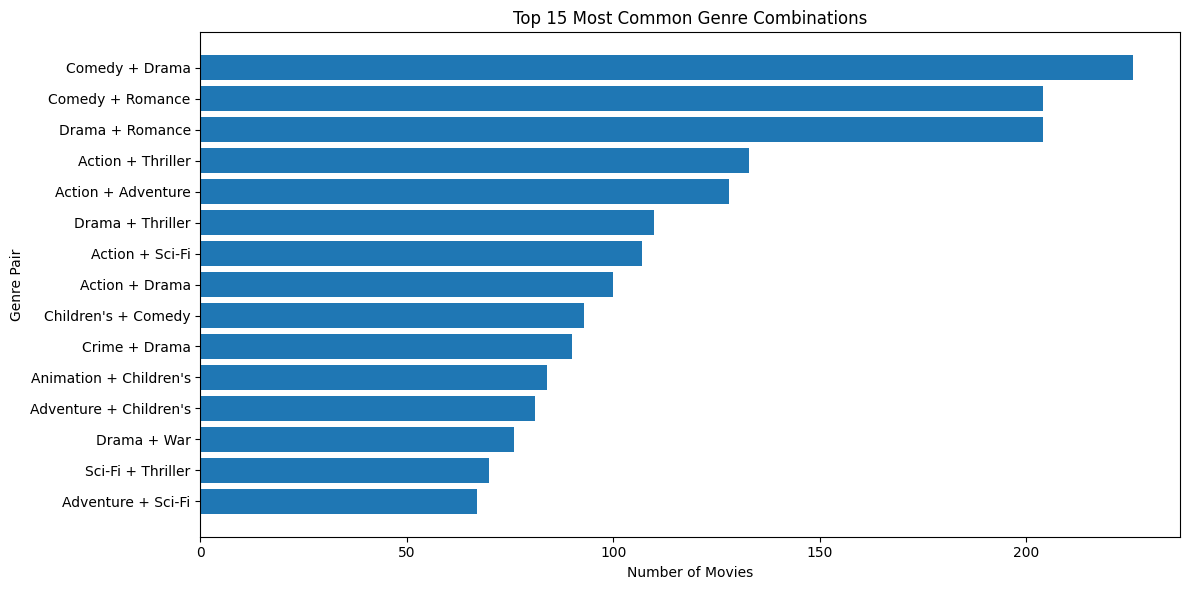

In [75]:
top_pairs = genre_pairs_count.head(15)

labels = [f"{pair[0]} + {pair[1]}" for pair in top_pairs.index]

plt.figure(figsize=(12, 6))
plt.barh(labels[::-1], top_pairs.values[::-1])

plt.xlabel("Number of Movies")
plt.ylabel("Genre Pair")
plt.title("Top 15 Most Common Genre Combinations")

plt.tight_layout()
plt.show()

In [76]:
total_movies = len(movies)

genre_pair_percentage = (
    genre_pairs_count / total_movies * 100
)

genre_pair_percentage.head(15)

Comedy      Drama         5.820242
            Romance       5.253670
Drama       Romance       5.253670
Action      Thriller      3.425187
            Adventure     3.296420
Drama       Thriller      2.832861
Action      Sci-Fi        2.755601
            Drama         2.575328
Children's  Comedy        2.395055
Crime       Drama         2.317796
Animation   Children's    2.163276
Adventure   Children's    2.086016
Drama       War           1.957250
Sci-Fi      Thriller      1.802730
Adventure   Sci-Fi        1.725470
Name: Movie_Count, dtype: float64

In [77]:
pair_ratings = []

for genres in movies["Genres"]:
    genre_list = genres.split("|")

    for pair in combinations(sorted(genre_list), 2):
        pair_ratings.append({
            "Genre_Pair": f"{pair[0]} + {pair[1]}",
            "MovieID": movies.loc[movies["Genres"] == genres, "MovieID"].iloc[0]
        })

pair_ratings_df = pd.DataFrame(pair_ratings)

pair_rating_analysis = (
    pair_ratings_df
    .merge(ratings, on="MovieID")
    .groupby("Genre_Pair")["Rating"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

pair_rating_analysis.head(15)

,count,mean
Genre_Pair,,
Drama + Romance,163672,3.933489
Comedy + Romance,119396,3.326058
Action + Adventure,88788,3.349529
Comedy + Drama,78202,3.408711
Action + Sci-Fi,76648,3.236549
Drama + Thriller,64906,3.754214
Action + Thriller,62898,3.329836
Action + War,56289,3.907300
Animation + Children's,55912,3.866970


In [78]:
pair_movie_df = movies[["MovieID", "Genres"]].copy()

pair_movie_df["Genre_List"] = pair_movie_df["Genres"].str.split("|")

pair_movie_df = pair_movie_df.explode("Genre_List")

pair_movie_df = pair_movie_df.rename(columns={"Genre_List": "Genre"})

# MovieID ke andar genre pairs banana
pair_list = []

for movie_id, group in pair_movie_df.groupby("MovieID"):
    genres = sorted(group["Genre"].unique())

    for pair in combinations(genres, 2):
        pair_list.append({
            "MovieID": movie_id,
            "Genre_Pair": f"{pair[0]} + {pair[1]}"
        })

pair_movie_pairs = pd.DataFrame(pair_list)

# Ratings ke saath merge
pair_rating_analysis = (
    pair_movie_pairs
    .merge(ratings[["MovieID", "Rating"]], on="MovieID")
    .groupby("Genre_Pair")["Rating"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

pair_rating_analysis.head(15)

,count,mean
Genre_Pair,,
Action + Sci-Fi,91290,3.467412
Action + Adventure,90323,3.497426
Action + Thriller,83582,3.468510
Comedy + Romance,71762,3.586787
Comedy + Drama,69138,3.719214
Adventure + Sci-Fi,56308,3.504120
Drama + Romance,56286,3.652969
Action + Drama,48916,3.761162
Sci-Fi + Thriller,44467,3.479929


In [79]:
pair_avg_rating = (
    pair_rating_analysis["mean"]
    .sort_values(ascending=False)
)

pair_avg_rating.head(15)

,mean
Genre_Pair,
Film-Noir + Romance,4.294382
Film-Noir + Mystery,4.137273
Film-Noir + Sci-Fi,4.126028
Animation + Thriller,4.111597
Film-Noir + Thriller,4.057611
Crime + Film-Noir,4.046493
Drama + War,4.025418
Adventure + War,4.001508
Film-Noir + Horror,4.000000


In [80]:
pair_summary = (
    pair_rating_analysis
    .sort_values("mean", ascending=False)
)

pair_summary.head(15)

,count,mean
Genre_Pair,,
Film-Noir + Romance,445,4.294382
Film-Noir + Mystery,6396,4.137273
Film-Noir + Sci-Fi,2674,4.126028
Animation + Thriller,1371,4.111597
Film-Noir + Thriller,9512,4.057611
Crime + Film-Noir,6388,4.046493
Drama + War,40798,4.025418
Adventure + War,10610,4.001508
Film-Noir + Horror,2,4.000000


In [81]:
reliable_pairs = pair_rating_analysis[
    pair_rating_analysis["count"] >= 500
].sort_values("mean", ascending=False)

reliable_pairs.head(15)

,count,mean
Genre_Pair,,
Film-Noir + Mystery,6396,4.137273
Film-Noir + Sci-Fi,2674,4.126028
Animation + Thriller,1371,4.111597
Film-Noir + Thriller,9512,4.057611
Crime + Film-Noir,6388,4.046493
Drama + War,40798,4.025418
Adventure + War,10610,4.001508
Romance + War,14887,3.966548
Crime + Romance,4696,3.941014


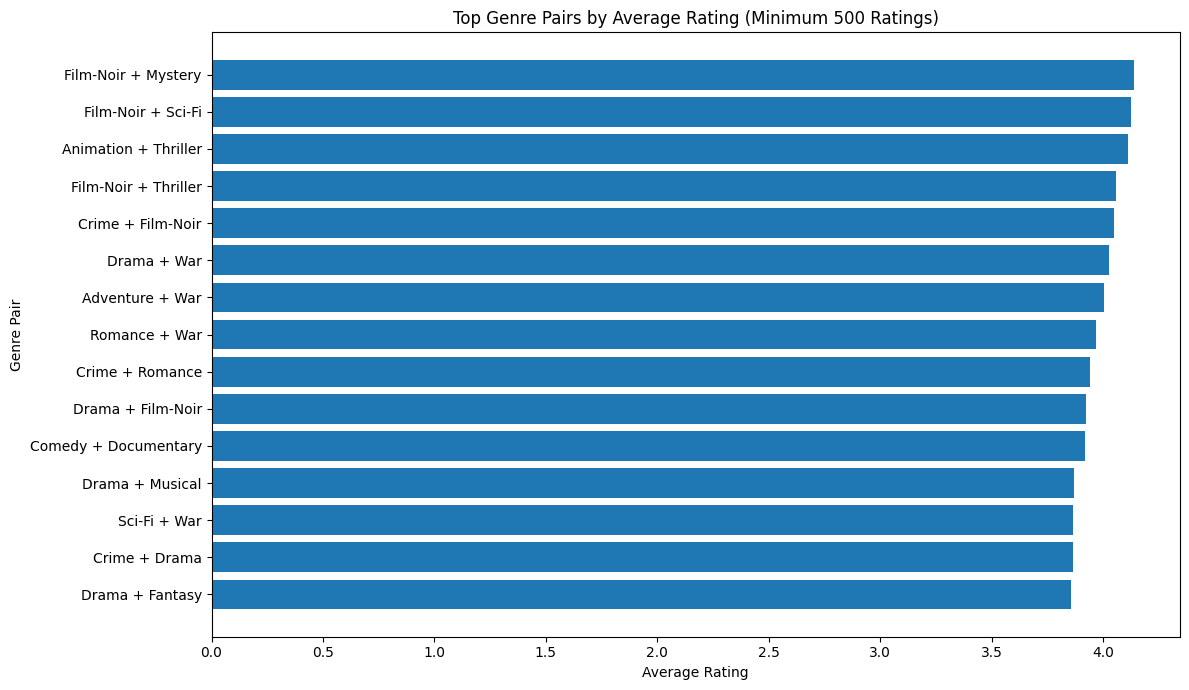

In [82]:
top_reliable_pairs = reliable_pairs.head(15)

labels = top_reliable_pairs.index

plt.figure(figsize=(12, 7))
plt.barh(labels[::-1], top_reliable_pairs["mean"][::-1])

plt.xlabel("Average Rating")
plt.ylabel("Genre Pair")
plt.title("Top Genre Pairs by Average Rating (Minimum 500 Ratings)")

plt.tight_layout()
plt.show()

In [83]:
from mlxtend.frequent_patterns import apriori, association_rules

genre_matrix = movies["Genres"].str.get_dummies(sep="|")

genre_matrix.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [84]:
frequent_genres = apriori(
    genre_matrix,
    min_support=0.02,
    use_colnames=True
)

frequent_genres.sort_values(
    "support",
    ascending=False
).head(15)

,support,itemsets
7,0.412825,(Drama)
4,0.309039,(Comedy)
0,0.129539,(Action)
13,0.126706,(Thriller)
11,0.121298,(Romance)
8,0.088334,(Horror)
1,0.072882,(Adventure)
12,0.071079,(Sci-Fi)
3,0.064641,(Children's)
22,0.058202,"(Comedy, Drama)"


In [85]:
rules = association_rules(
    frequent_genres,
    metric="confidence",
    min_threshold=0.3
)

rules = rules.sort_values("lift", ascending=False)

rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(15)

,antecedents,consequents,support,confidence,lift
3,(Children's),(Animation),0.021633,0.334661,12.376096
4,(Animation),(Children's),0.021633,0.800000,12.376096
2,(Children's),(Adventure),0.020860,0.322709,4.427843
0,(Adventure),(Action),0.032964,0.452297,3.491588
1,(Sci-Fi),(Action),0.027556,0.387681,2.992775
6,(Romance),(Comedy),0.052537,0.433121,1.401507
5,(Children's),(Comedy),0.023951,0.370518,1.198934
8,(Romance),(Drama),0.052537,0.433121,1.049163
7,(Crime),(Drama),0.023178,0.426540,1.033223


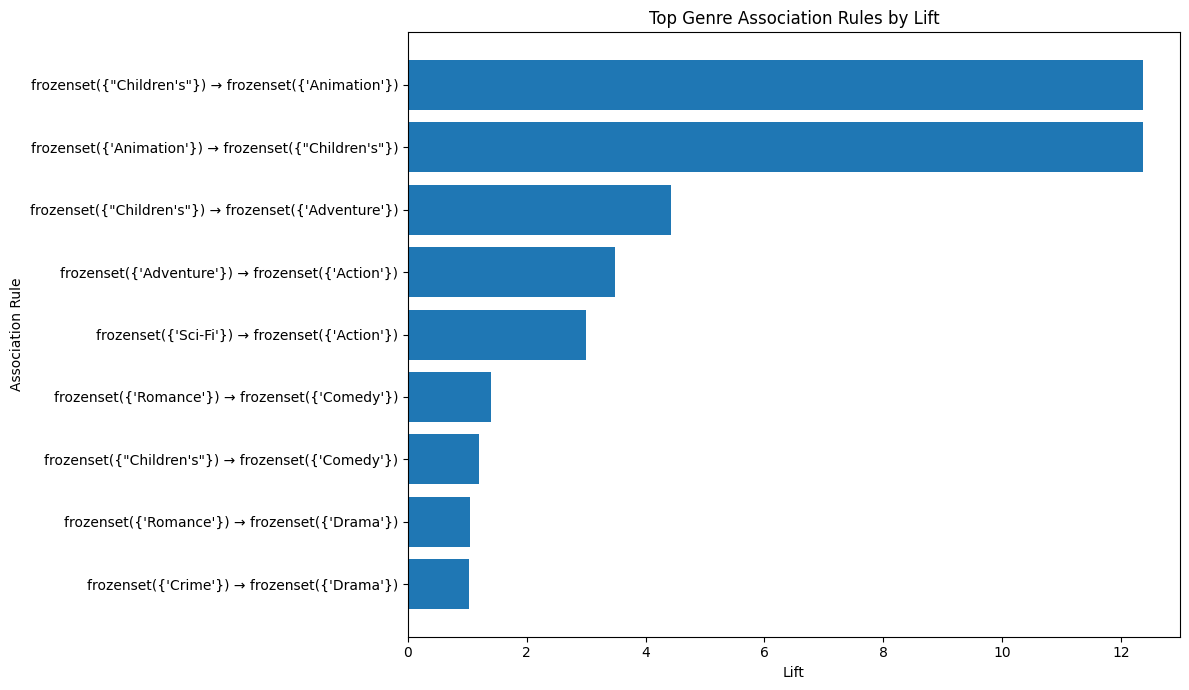

In [86]:
top_rules = rules.head(10).copy()

top_rules["Rule"] = (
    top_rules["antecedents"].astype(str)
    + " → "
    + top_rules["consequents"].astype(str)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_rules["Rule"][::-1],
    top_rules["lift"][::-1]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top Genre Association Rules by Lift")

plt.tight_layout()
plt.show()

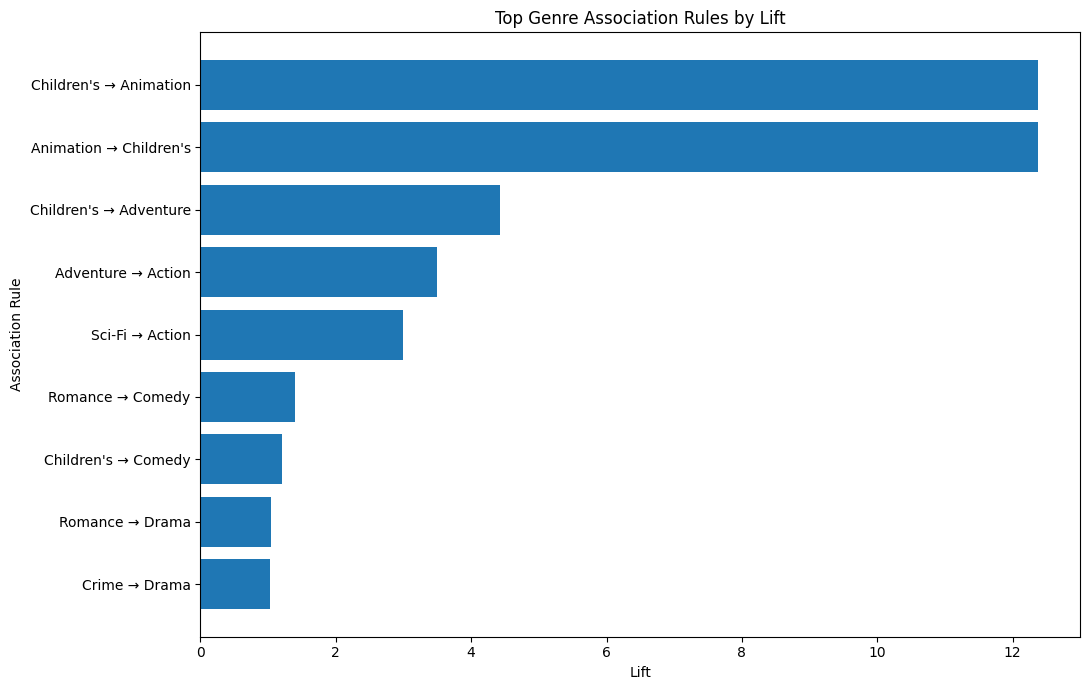

In [87]:
top_rules = rules.head(10).copy()

top_rules["Rule"] = top_rules.apply(
    lambda row: f"{', '.join(row['antecedents'])} → {', '.join(row['consequents'])}",
    axis=1
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_rules["Rule"][::-1],
    top_rules["lift"][::-1]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top Genre Association Rules by Lift")

plt.tight_layout()
plt.show()

In [88]:
final_rules = top_rules[[
    "Rule",
    "support",
    "confidence",
    "lift"
]].copy()

final_rules["support"] = (final_rules["support"] * 100).round(2)
final_rules["confidence"] = (final_rules["confidence"] * 100).round(2)
final_rules["lift"] = final_rules["lift"].round(2)

final_rules.columns = [
    "Association Rule",
    "Support (%)",
    "Confidence (%)",
    "Lift"
]

final_rules

,Association Rule,Support (%),Confidence (%),Lift
3,Children's → Animation,2.16,33.47,12.38
4,Animation → Children's,2.16,80.00,12.38
2,Children's → Adventure,2.09,32.27,4.43
0,Adventure → Action,3.30,45.23,3.49
1,Sci-Fi → Action,2.76,38.77,2.99
6,Romance → Comedy,5.25,43.31,1.40
5,Children's → Comedy,2.40,37.05,1.20
8,Romance → Drama,5.25,43.31,1.05
7,Crime → Drama,2.32,42.65,1.03


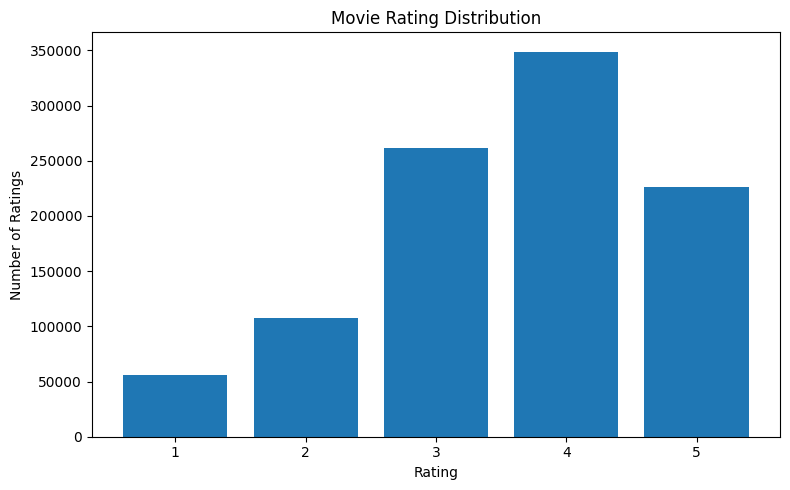

In [89]:
rating_counts = ratings["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Movie Rating Distribution")

plt.tight_layout()
plt.show()

In [90]:
rating_percentage = (
    ratings["Rating"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

rating_percentage.round(2)

,proportion
Rating,
1,5.62
2,10.75
3,26.11
4,34.89
5,22.63


In [91]:
print("===== MOVIE GENRE & RATING PATTERN MINING =====\n")

print("1. Total Movies:", len(movies))
print("2. Total Ratings:", len(ratings))
print("3. Overall Average Rating:", round(ratings["Rating"].mean(), 2))

print("\n4. Most Common Rating:",
      ratings["Rating"].value_counts().idxmax())

print("5. Most Rated Genre:",
      genre_df["Genre"].value_counts().idxmax())

print("6. Highest Average Rated Genre:",
      genre_df.groupby("Genre")["Rating"].mean().idxmax())

print("7. Highest Average Rated Genre Pair:",
      reliable_pairs["mean"].idxmax())

print("8. Strongest Association Rule:",
      final_rules.iloc[0]["Association Rule"])

print("   Lift:", final_rules.iloc[0]["Lift"])

===== MOVIE GENRE & RATING PATTERN MINING =====

1. Total Movies: 3883
2. Total Ratings: 1000209
3. Overall Average Rating: 3.58

4. Most Common Rating: 4
5. Most Rated Genre: Comedy
6. Highest Average Rated Genre: Film-Noir
7. Highest Average Rated Genre Pair: Film-Noir + Mystery
8. Strongest Association Rule: Children's → Animation
   Lift: 12.38


In [92]:
final_insights = pd.DataFrame({
    "Finding": [
        "Total Movies",
        "Total Ratings",
        "Average Rating",
        "Most Common Rating",
        "Most Rated Genre",
        "Highest Average Rated Genre",
        "Highest Average Rated Genre Pair",
        "Highest-Lift Association Rule"
    ],
    "Result": [
        len(movies),
        len(ratings),
        round(ratings["Rating"].mean(), 2),
        ratings["Rating"].value_counts().idxmax(),
        genre_df["Genre"].value_counts().idxmax(),
        genre_df.groupby("Genre")["Rating"].mean().idxmax(),
        reliable_pairs["mean"].idxmax(),
        final_rules.iloc[0]["Association Rule"]
    ]
})

final_insights

,Finding,Result
0,Total Movies,3883
1,Total Ratings,1000209
2,Average Rating,3.58
3,Most Common Rating,4
4,Most Rated Genre,Comedy
5,Highest Average Rated Genre,Film-Noir
6,Highest Average Rated Genre Pair,Film-Noir + Mystery
7,Highest-Lift Association Rule,Children's → Animation


In [93]:
print("""
===== FINAL PROJECT CONCLUSION =====

MovieLens 1M dataset was analyzed using Data Mining techniques.

• 3,883 movies and 1,000,209 ratings were analyzed.
• The overall average movie rating was 3.58.
• Rating 4 was the most common rating.
• Comedy was the most frequently rated genre.
• Film-Noir had the highest average rating.
• Film-Noir + Mystery had the highest average rating among reliable genre pairs.
• Association Rule Mining revealed strong genre relationships.
• Children's → Animation had the highest Lift of 12.38.

The analysis identified rating patterns, genre preferences,
genre combinations, and association rules from the dataset.
""")


===== FINAL PROJECT CONCLUSION =====

MovieLens 1M dataset was analyzed using Data Mining techniques.

• 3,883 movies and 1,000,209 ratings were analyzed.
• The overall average movie rating was 3.58.
• Rating 4 was the most common rating.
• Comedy was the most frequently rated genre.
• Film-Noir had the highest average rating.
• Film-Noir + Mystery had the highest average rating among reliable genre pairs.
• Association Rule Mining revealed strong genre relationships.
• Children's → Animation had the highest Lift of 12.38.

The analysis identified rating patterns, genre preferences,
genre combinations, and association rules from the dataset.



In [94]:
# Age Group vs Most Watched Movie Genres

age_genre_count = (
    genre_df
    .merge(
        users[["UserID", "Age_Group"]],
        on="UserID"
    )
    .groupby(["Age_Group", "Genre"])
    .size()
    .reset_index(name="Movie_Count")
)

# Top 5 genres for each age group
top_genres_by_age = (
    age_genre_count
    .sort_values(["Age_Group", "Movie_Count"], ascending=[True, False])
    .groupby("Age_Group")
    .head(5)
)

display(top_genres_by_age)

,Age_Group,Genre,Movie_Count
4,18-24,Comedy,69980
7,18-24,Drama,58104
0,18-24,Action,50186
15,18-24,Thriller,35877
14,18-24,Sci-Fi,29033
22,25-34,Comedy,143210
25,25-34,Drama,138695
18,25-34,Action,105678
33,25-34,Thriller,77429
32,25-34,Sci-Fi,63156


In [95]:
# Top 3 Most Watched Genres for Each Age Group

top3_genres_by_age = (
    age_genre_count
    .sort_values(["Age_Group", "Movie_Count"], ascending=[True, False])
    .groupby("Age_Group")
    .head(3)
)

display(top3_genres_by_age)

,Age_Group,Genre,Movie_Count
4,18-24,Comedy,69980
7,18-24,Drama,58104
0,18-24,Action,50186
22,25-34,Comedy,143210
25,25-34,Drama,138695
18,25-34,Action,105678
43,35-44,Drama,71590
40,35-44,Comedy,69244
36,35-44,Action,50503
61,45-49,Drama,32141


In [96]:
print("===== AGE GROUP vs MOVIE GENRE PREFERENCE =====\n")

for age_group in age_genre_count["Age_Group"].unique():

    temp = (
        age_genre_count[
            age_genre_count["Age_Group"] == age_group
        ]
        .sort_values("Movie_Count", ascending=False)
        .head(3)
    )

    genres = ", ".join(temp["Genre"])

    print(f"{age_group}: {genres}")

===== AGE GROUP vs MOVIE GENRE PREFERENCE =====

18-24: Comedy, Drama, Action
25-34: Comedy, Drama, Action
35-44: Drama, Comedy, Action
45-49: Drama, Comedy, Action
50-55: Drama, Comedy, Action
56+: Drama, Comedy, Action
Under 18: Comedy, Drama, Action


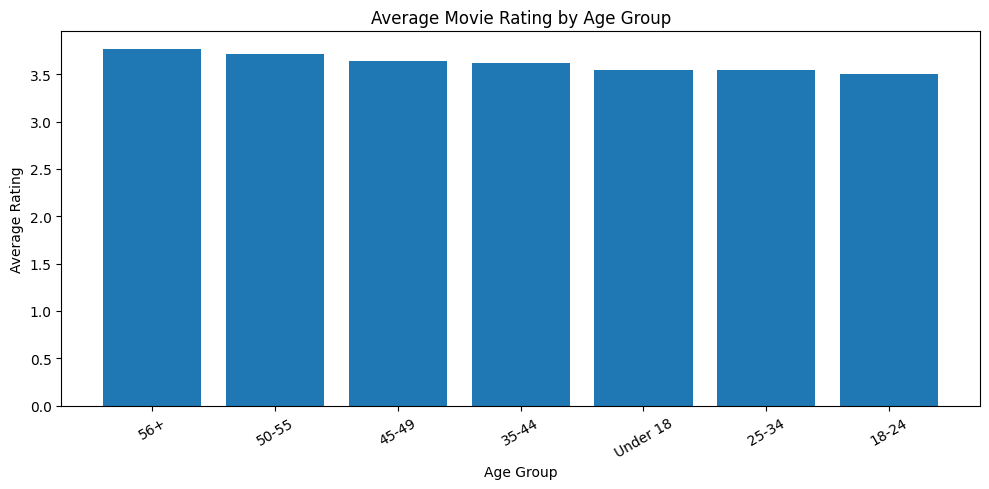

In [100]:
import matplotlib.pyplot as plt

age_rating = (
    age_ratings.groupby("Age_Group")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(age_rating.index, age_rating.values)

plt.xlabel("Age Group")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Age Group")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

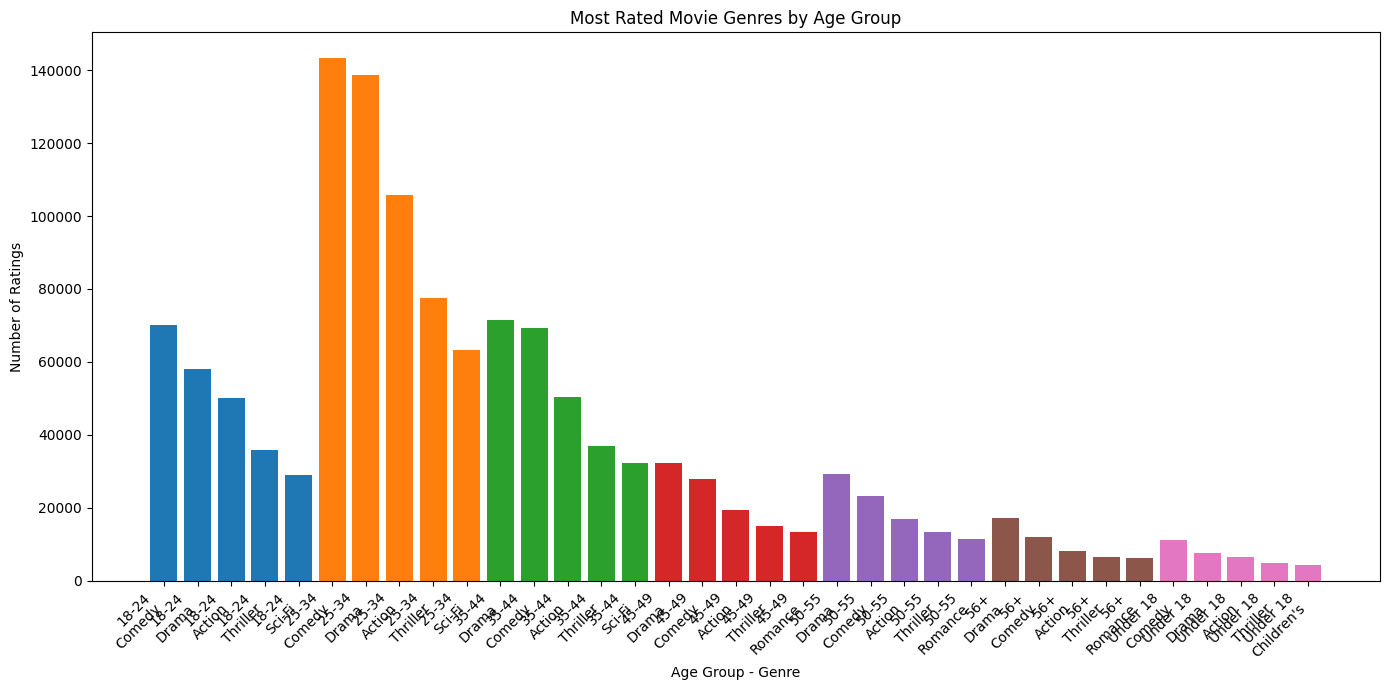

In [101]:
# Age Group vs Most Rated Movie Genres

age_genre_count = (
    genre_df
    .merge(
        users[["UserID", "Age_Group"]],
        on="UserID"
    )
    .groupby(["Age_Group", "Genre"])
    .size()
    .reset_index(name="Count")
)

# Top 5 genres for each age group
top5_age_genre = (
    age_genre_count
    .sort_values(["Age_Group", "Count"], ascending=[True, False])
    .groupby("Age_Group")
    .head(5)
)

# Bar Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for age_group in top5_age_genre["Age_Group"].unique():
    data = top5_age_genre[top5_age_genre["Age_Group"] == age_group]

    plt.bar(
        [f"{age_group}\n{genre}" for genre in data["Genre"]],
        data["Count"]
    )

plt.xlabel("Age Group - Genre")
plt.ylabel("Number of Ratings")
plt.title("Most Rated Movie Genres by Age Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

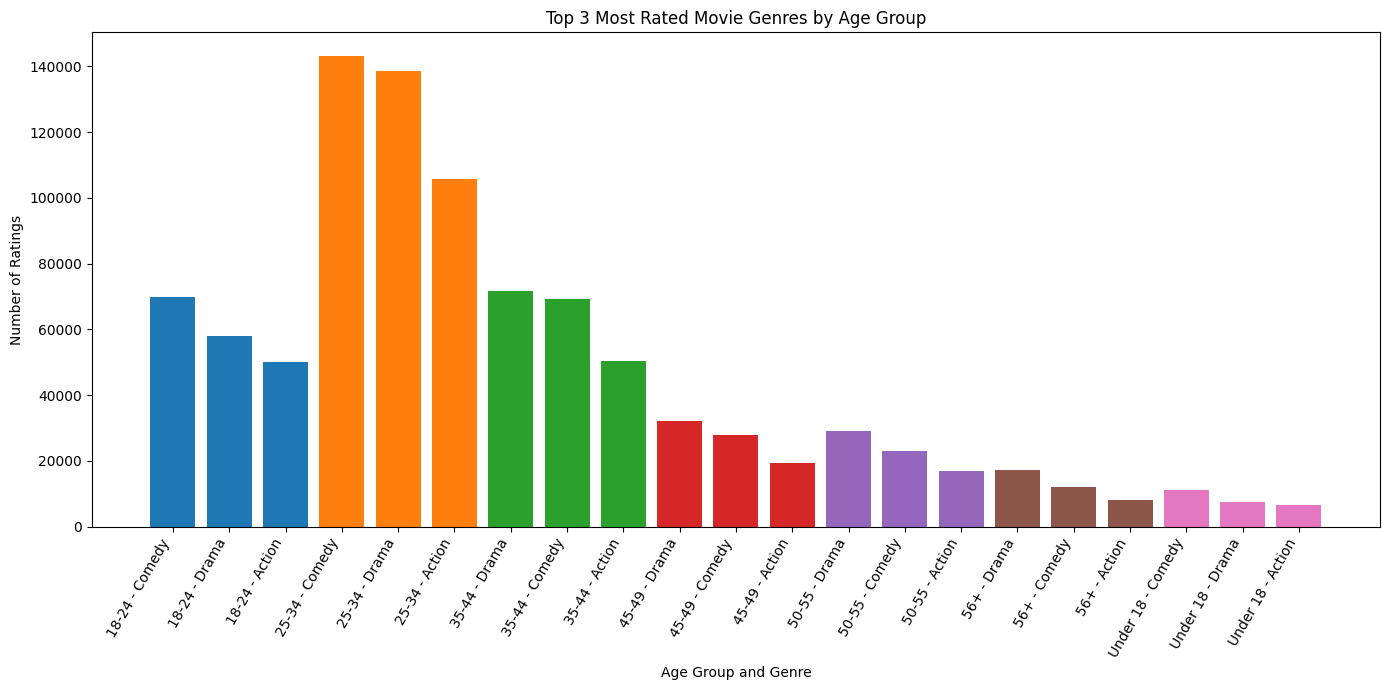

In [102]:
# Top 3 Movie Genres for Each Age Group

top3_age_genre = (
    age_genre_count
    .sort_values(["Age_Group", "Count"], ascending=[True, False])
    .groupby("Age_Group")
    .head(3)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for age_group in top3_age_genre["Age_Group"].unique():
    data = top3_age_genre[
        top3_age_genre["Age_Group"] == age_group
    ]

    plt.bar(
        [f"{age_group} - {genre}" for genre in data["Genre"]],
        data["Count"]
    )

plt.xlabel("Age Group and Genre")
plt.ylabel("Number of Ratings")
plt.title("Top 3 Most Rated Movie Genres by Age Group")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

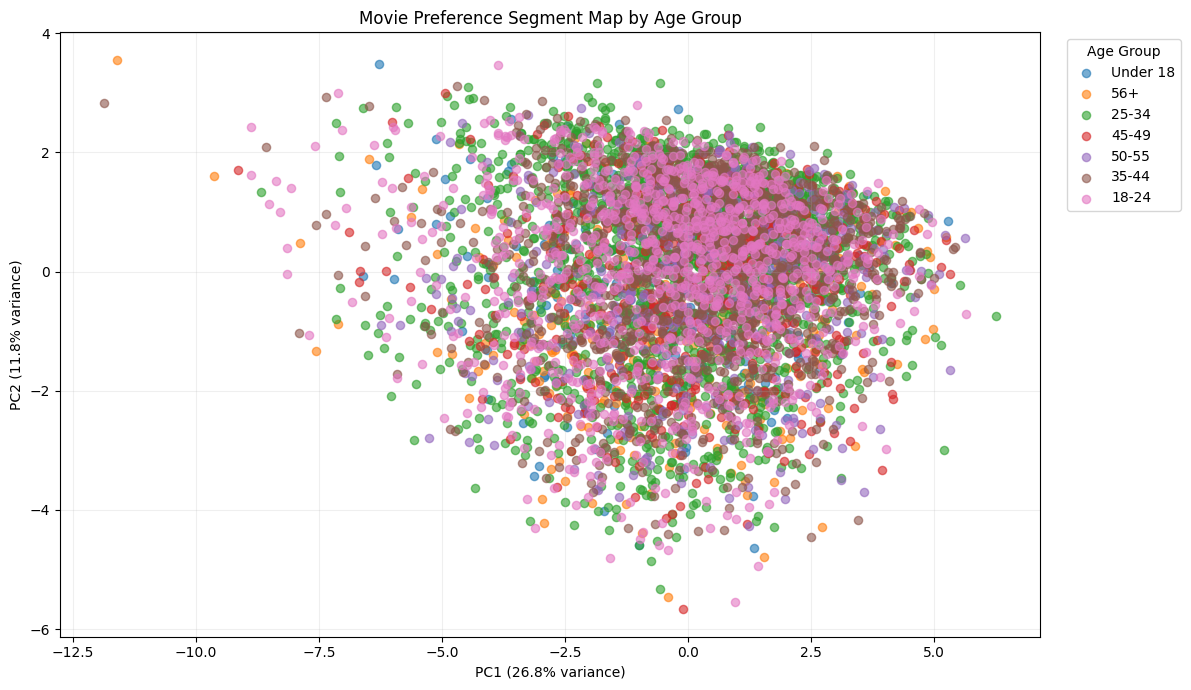

In [103]:
# ==========================================
# Movie Preference Segment Map using PCA
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Create User-Genre rating matrix
user_genre = (
    genre_df
    .merge(
        users[["UserID", "Age_Group"]],
        on="UserID"
    )
    .groupby(["UserID", "Genre"])["Rating"]
    .mean()
    .unstack(fill_value=0)
)

# Add Age Group for each user
user_age = users.set_index("UserID")["Age_Group"]

user_genre["Age_Group"] = user_genre.index.map(user_age)

# Separate features and age group
X = user_genre.drop(columns=["Age_Group"])

# Standardize genre preferences
X_scaled = StandardScaler().fit_transform(X)

# PCA - reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=user_genre.index
)

pca_df["Age_Group"] = user_genre["Age_Group"]

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(12, 7))

age_groups = pca_df["Age_Group"].unique()

for age in age_groups:
    data = pca_df[pca_df["Age_Group"] == age]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        s=35,
        alpha=0.6,
        label=age
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("Movie Preference Segment Map by Age Group")

plt.legend(
    title="Age Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()